In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib.dates as mdates
import matplotlib.ticker as ticker


superstore = pd.read_csv("superstore.csv")
superstore['Order Date'] = pd.to_datetime(superstore['Order Date'])

yearly_sales = superstore.groupby(superstore["Order Date"].dt.year)["Sales"].sum()
sales = pd.DataFrame({"year":superstore["Order Date"].dt.year.unique(), "sales":yearly_sales})

sales.to_csv('apps/public/yearly_sales.csv')


/var/folders/3_/8bgmkbdj7vz5fh4m_ppttn_c0000gp/T/ipykernel_35657/2807504929.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  superstore['Order Date'] = pd.to_datetime(superstore['Order Date'])


In [4]:
yearly_sales_by_segment = (
    superstore.groupby([pd.Grouper(key="Order Date", freq="YE"), "Segment"], as_index=False).agg(sales=("Sales", "sum"))
)
yearly_sales_by_segment["Order Date"] = pd.to_datetime(yearly_sales_by_segment["Order Date"])
yearly_sales_by_segment['year'] = yearly_sales_by_segment["Order Date"].dt.year

yearly_sales_by_segment.to_csv('apps/public/yearly_sales_by_segment.csv')

In [5]:
weekly_sales_by_segment = (
    superstore.groupby([pd.Grouper(key="Order Date", freq="W-MON"), "Segment"], as_index=False).agg(sales=("Sales", "sum"))
)
weekly_sales_by_segment["Order Date"] = pd.to_datetime(weekly_sales_by_segment["Order Date"])
#weekly_sales_by_segment['week'] = weekly_sales_by_segment["Order Date"].dt.week

weekly_sales_by_segment['truncated'] = weekly_sales_by_segment['sales']/1_000
weekly_sales_by_segment['truncated'] = weekly_sales_by_segment['truncated'].round()

weekly_sales_by_segment.to_csv('apps/public/weekly_sales_by_segment.csv')

In [20]:
superstore['Sales'].to_csv('apps/public/raw_sales.csv')

In [ ]:
#superstore['Sales'].hist(bins=100)
import numpy as np

counts, bin_edges = np.histogram(superstore['Sales'], bins=20)

In [12]:
counts

array([49131,  1619,   385,    95,    32,    12,     2,     6,     3,
           2,     0,     0,     1,     0,     0,     1,     0,     0,
           0,     1])

In [13]:
bin_edges

array([4.44000000e-01, 1.13234580e+03, 2.26424760e+03, 3.39614940e+03,
       4.52805120e+03, 5.65995300e+03, 6.79185480e+03, 7.92375660e+03,
       9.05565840e+03, 1.01875602e+04, 1.13194620e+04, 1.24513638e+04,
       1.35832656e+04, 1.47151674e+04, 1.58470692e+04, 1.69789710e+04,
       1.81108728e+04, 1.92427746e+04, 2.03746764e+04, 2.15065782e+04,
       2.26384800e+04])

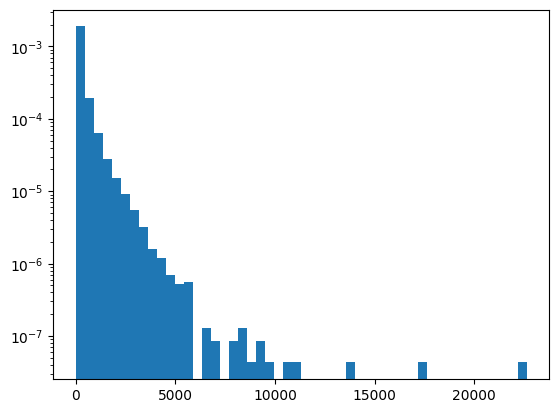

In [24]:
import numpy as np
import matplotlib.pyplot as plt

x, bins, p = plt.hist(superstore[superstore['Sales'] > 0]['Sales'], density=True, log=True, bins=50)
plt.show()

In [22]:
np.min(superstore['Sales'])

np.float64(0.444)